# Data Storytelling : การเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ


---

แหล่งที่มาข้อมูล: https://data.hii.or.th/
ชุดข้อมูลใน THackle: https://www.thackle.or.th/th/dataset/94



---

## 🗺️ โครงสร้าง Notebook
1. Setup & Load Data
2. Data Preparation
3. Data Cleaning
4. EDA เบื้องต้น
5. โจทย์ข้อที่ 1
6. โจทย์ข้อที่ 2
7. โจทย์ข้อที่ 3


# Setup & Load Data

In [208]:
# ติดตั้ง library เพิ่มเติม
%pip install plotly kaleido -q

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# ดาวน์โหลดฟอนต์ภาษาไทย (Sukhumvit-Medium)
!curl -L -o SukhumvitSet-Medium.ttf https://github.com/bluenex/baansuan_prannok/raw/master/fonts/sukhumvit-set/SukhumvitSet-Medium.ttf

# ตั้งค่า Font
font_path = 'SukhumvitSet-Medium.ttf'
mpl.font_manager.fontManager.addfont(font_path)
prop = mpl.font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print(f"Detected Font Name: {font_name}")
plt.rcParams['font.family'] = font_name
sns.set_theme(style="whitegrid", font=font_name)

# ตั้งค่า style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

print('Setup Completed')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 84932  100 84932    0     0   197k      0 --:--:-- --:--:-- --:--:--  197k
Detected Font Name: Sukhumvit Set
Setup Completed


In [209]:
# โหลดข้อมูลจาก Dataset โดยแบ่งเป็นปี 2025 และปี 2026
raw_url_2025 = 'https://raw.githubusercontent.com/Theerat22/superAI/main/mini-hack1/uploads1-9-20260312-160940321.csv'
raw_url_2026 = 'https://raw.githubusercontent.com/Theerat22/superAI/main/mini-hack1/uploads1-9-20260312-160940030.csv'

df_2025 = pd.read_csv(raw_url_2025, encoding='utf-8-sig')
df_2026 = pd.read_csv(raw_url_2026, encoding='utf-8-sig')

# Data Preparation

In [210]:
# ดูตัวอย่างข้อมูลไฟล์ CSV
print('='*60)
print('2025')
print(f'{df_2025.shape[0]:} rows | column {df_2025.shape[1]} columns')
print(f'columns : {df_2025.columns.tolist()}')

print('='*60)
print('2026')
print(f'{df_2026.shape[0]:} rows | column {df_2026.shape[1]} columns')
print(f'columns : {df_2026.columns.tolist()}')

print('='*60)
print('2025 Example :')
display(df_2025.head(3))
display(df_2025.tail(3))

print('='*60)

print('2026 Example :')
display(df_2026.head(3))
display(df_2026.tail(3))


2025
69440 rows | column 8 columns
columns : ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ']
2026
3010 rows | column 8 columns
columns : ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ']
2025 Example :


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2025,คน,"127,551"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2025,คน,"8,218"
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2025,คัน,"877,943"


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
69437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2026 Example :


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2026,คน,"112,325"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2026,คน,0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2026,คัน,"892,218"


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
3007,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,11/03/2026,คน,"11,625"
3008,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,11/03/2026,คน,998
3009,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาออกประเทศ,11/03/2026,คน,"1,113"


In [211]:
# ดูประเภทข้อมูลว่ามีประเภทอะไรบ้าง
df_2025.info()
print()
df_2026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69440 entries, 0 to 69439
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   รูปแบบการเดินทาง   15696 non-null  object
 1   วัตถุประสงค์       15696 non-null  object
 2   สาธารณะ/ส่วนบุคคล  15696 non-null  object
 3   หน่วยงาน           15696 non-null  object
 4   ยานพาหนะ/ท่า       15696 non-null  object
 5   วันที่             15696 non-null  object
 6   หน่วย              15696 non-null  object
 7   ปริมาณ             15388 non-null  object
dtypes: object(8)
memory usage: 4.2+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   รูปแบบการเดินทาง   3010 non-null   object
 1   วัตถุประสงค์       3010 non-null   object
 2   สาธารณะ/ส่วนบุคคล  3010 non-null   object
 3   หน่วยงาน           3010 non-null   

จะสังเกตได้ว่าทุกข้อมูลในไฟล์เป็น object หมดจึงทำให้นำมาวิเคราะห์ต่อไม่ได้ จึงได้ทำการแปลงข้อมูลวันที่ และปริมาณ เป็น datetime และ float

In [212]:
# เปลี่ยนปริมาณจาก object เป็น float
df_2025['ปริมาณ'] = df_2025['ปริมาณ'].astype(str).str.replace(',', '').astype(float)
df_2026['ปริมาณ'] = df_2026['ปริมาณ'].astype(str).str.replace(',', '').astype(float)

# เปลี่ยนวันที่จาก object เป็น datetime
df_2025['วันที่'] = pd.to_datetime(df_2025['วันที่'], format='%d/%m/%Y')
df_2026['วันที่'] = pd.to_datetime(df_2026['วันที่'], format='%d/%m/%Y')

In [213]:
# สถิติเบื้องต้น
for year, df in [('2025', df_2025), ('2026', df_2026)]:
    total = int(df['ปริมาณ'].sum())
    null_count = df.isnull().sum().sum()
    pass_count = df['ปริมาณ'].nunique()
    mode_count = df['รูปแบบการเดินทาง'].nunique()
    purpose_count = df['วัตถุประสงค์'].nunique()
    station_count = df['ยานพาหนะ/ท่า'].nunique()

    print(f'ปี {year}')
    print(f'   จำนวนปริมาณ : {pass_count} คน')
    print(f'   รูปแบบการเดินทาง : {mode_count} แบบ')
    print(f'   วัตถุประสงค์การเดินทาง : {purpose_count} แบบ')
    print(f'   ยานพาหนะ/ท่า : {station_count} แบบ')
    print(f'   ⚠️ ค่า Null : {null_count} ค่า')
    print()

ปี 2025
   จำนวนปริมาณ : 12162 คน
   รูปแบบการเดินทาง : 4 แบบ
   วัตถุประสงค์การเดินทาง : 3 แบบ
   ยานพาหนะ/ท่า : 43 แบบ
   ⚠️ ค่า Null : 430260 ค่า

ปี 2026
   จำนวนปริมาณ : 2528 คน
   รูปแบบการเดินทาง : 4 แบบ
   วัตถุประสงค์การเดินทาง : 3 แบบ
   ยานพาหนะ/ท่า : 43 แบบ
   ⚠️ ค่า Null : 136 ค่า



จะสังเกตได้ว่าข้อมูล csv ที่ได้มามีค่า null รวมกันทั้งหมดเยอะมากถึง 430,396 ค่า

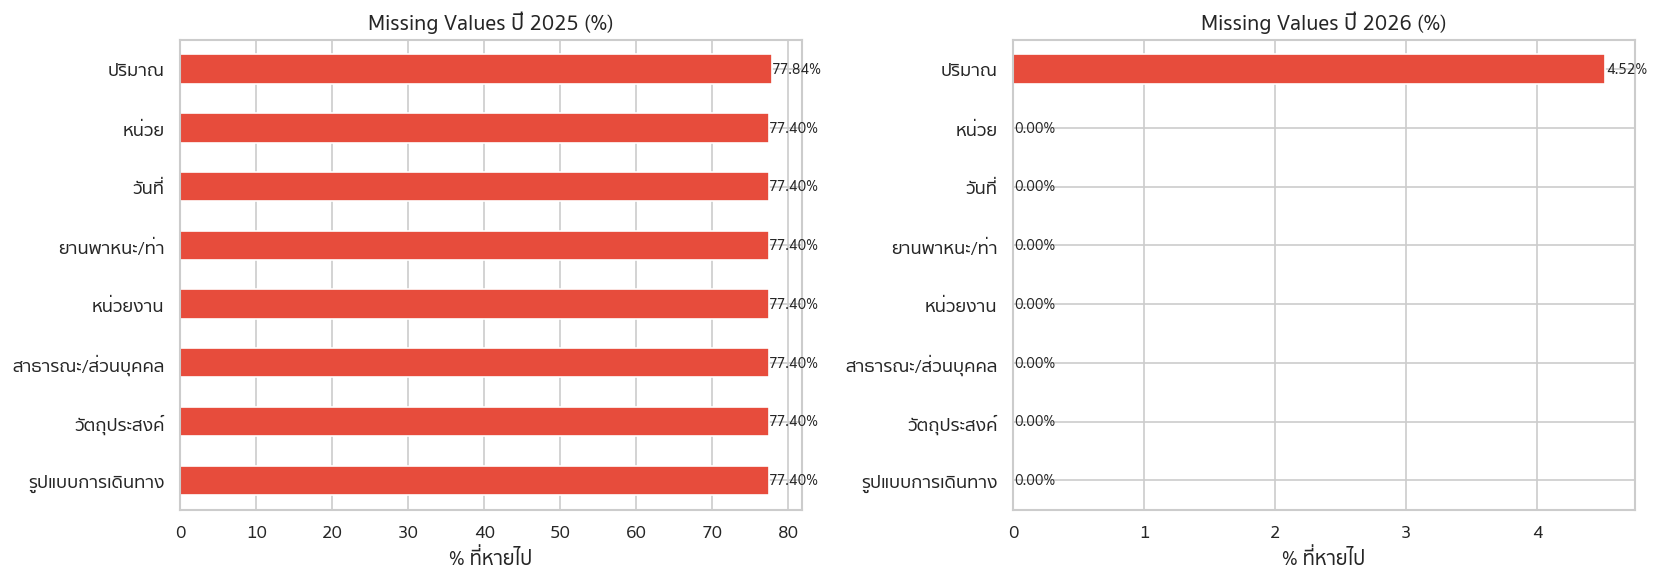

💡 แดง = มีค่า null


In [214]:
# ดู Missing Values แบบ Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (year, df) in zip(axes, [('2025', df_2025), ('2026', df_2026)]):
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in null_pct]
    null_pct.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Missing Values ปี {year} (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('% ที่หายไป')
    for i, v in enumerate(null_pct):
        ax.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('💡 แดง = มีค่า null' )

In [215]:
# เช็คว่าแต่ละ column มีข้อมูลว่างเท่าไหร่
print('Null Data!!!!')
print('-'*50)


print('2025 : ')
print(df_2025.isnull().sum())

print('='*50)
print('2026 : ')
print(df_2026.isnull().sum())

Null Data!!!!
--------------------------------------------------
2025 : 
รูปแบบการเดินทาง     53744
วัตถุประสงค์         53744
สาธารณะ/ส่วนบุคคล    53744
หน่วยงาน             53744
ยานพาหนะ/ท่า         53744
วันที่               53744
หน่วย                53744
ปริมาณ               54052
dtype: int64
2026 : 
รูปแบบการเดินทาง       0
วัตถุประสงค์           0
สาธารณะ/ส่วนบุคคล      0
หน่วยงาน               0
ยานพาหนะ/ท่า           0
วันที่                 0
หน่วย                  0
ปริมาณ               136
dtype: int64


# Data Cleaning

จากการเช็คข้อมูลเบื้องต้น จะเห็นว่ามีข้อมูลที่เป็น Null Data เยอะมากจึงทำการลบแถวที่เป็นข้อมูลว่างออกก่อน แต่ยกเว้น column ปริมาณ เพราะว่ามี Null Data ที่ไม่เท่ากับแถวอื่น

In [216]:
# ลบแถวที่ข้อมูลว่าง ในคอลัมน์หลักออก
df_2025.dropna(subset=['รูปแบบการเดินทาง', 'ยานพาหนะ/ท่า'], inplace=True)
df_2026.dropna(subset=['รูปแบบการเดินทาง', 'ยานพาหนะ/ท่า'], inplace=True)
print('✅ ลบแถวที่มีข้อมูลว่างแล้วเรียบร้อย')

✅ ลบแถวที่มีข้อมูลว่างแล้วเรียบร้อย


In [217]:
print('Null Data!!!!')
print('-'*50)


print('2025 : ')
print(df_2025.isnull().sum())

print('='*50)
print('2026 : ')
print(df_2026.isnull().sum())

Null Data!!!!
--------------------------------------------------
2025 : 
รูปแบบการเดินทาง       0
วัตถุประสงค์           0
สาธารณะ/ส่วนบุคคล      0
หน่วยงาน               0
ยานพาหนะ/ท่า           0
วันที่                 0
หน่วย                  0
ปริมาณ               308
dtype: int64
2026 : 
รูปแบบการเดินทาง       0
วัตถุประสงค์           0
สาธารณะ/ส่วนบุคคล      0
หน่วยงาน               0
ยานพาหนะ/ท่า           0
วันที่                 0
หน่วย                  0
ปริมาณ               136
dtype: int64


และสังเกตว่าข้อมูลที่เป็น null เฉพาะคอลลัมน์ปริมาณ ดังนั้นจึงทำการแทนค่า null ด้วยเลข 0

In [218]:
# แทนค่า Null ในคอลัมน์ 'ปริมาณ' ด้วย 0
df_2025['ปริมาณ'] = df_2025['ปริมาณ'].fillna(0)
df_2026['ปริมาณ'] = df_2026['ปริมาณ'].fillna(0)
print('✅ เติมเลข 0 ลงใน column ปริมาณที่ว่างแล้วเรียบร้อย')

✅ เติมเลข 0 ลงใน column ปริมาณที่ว่างแล้วเรียบร้อย


In [219]:
print('ตรวจสอบ Null Data อีกรอบ')
print('-'*50)


print('2025 : ')
print(df_2025.isnull().sum())

print('='*50)
print('2026 : ')
print(df_2026.isnull().sum())

ตรวจสอบ Null Data อีกรอบ
--------------------------------------------------
2025 : 
รูปแบบการเดินทาง     0
วัตถุประสงค์         0
สาธารณะ/ส่วนบุคคล    0
หน่วยงาน             0
ยานพาหนะ/ท่า         0
วันที่               0
หน่วย                0
ปริมาณ               0
dtype: int64
2026 : 
รูปแบบการเดินทาง     0
วัตถุประสงค์         0
สาธารณะ/ส่วนบุคคล    0
หน่วยงาน             0
ยานพาหนะ/ท่า         0
วันที่               0
หน่วย                0
ปริมาณ               0
dtype: int64


เมื่อลองเช็คข้อมูลแล้วอีกรอบ จะเห็นได้ว่าไม่มีข้อมูลที่เป็น Null แล้ว

In [220]:
# รวมข้อมูลทั้งสองปีเข้าด้วยกัน
df_all = pd.concat([df_2025, df_2026], ignore_index=True)

print('✅ รวมข้อมูลทั้งสองปีเข้าด้วยกันแล้ว')
display(df_all)

✅ รวมข้อมูลทั้งสองปีเข้าด้วยกันแล้ว


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,2025-01-01,คน,127551.0
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,2025-01-01,คน,8218.0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),2025-01-01,คัน,877943.0
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),2025-01-01,คัน,932642.0
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),2025-01-01,คัน,1364992.0
...,...,...,...,...,...,...,...,...
18701,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานดอนเมือง ขาออกประเทศ,2026-03-11,คน,16641.0
18702,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ,2026-03-11,คน,12741.0
18703,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,2026-03-11,คน,11625.0
18704,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,2026-03-11,คน,998.0


# EDA เบื้องต้น


**การวิเคราะห์เชิงสถิติเบื้องต้น**

- Distribution ของตัวแปรหลัก
- KPI สำคัญที่ต้องรู้

In [221]:
df_people = df_all[df_all['หน่วย'] == 'คน']
df_car = df_all[df_all['หน่วย'] == 'คัน']

# คำนวณค่าที่สำคัญ
total_p = df_people['ปริมาณ'].sum()
avg_p = df_people['ปริมาณ'].mean()
top_spot = df_people.loc[df_people['ปริมาณ'].idxmax()]
min_spot = df_people.loc[df_people['ปริมาณ'].idxmin()]


print('='*65)
print(f"{'🚀 สรุปภาพรวมสถิติการเดินทาง (KPI)':^65}")
print('='*65)

# ส่วนที่ 1: ข้อมูลพื้นฐาน
print(f"  📅 ช่วงเวลาที่เก็บข้อมูล   : {df_all['วันที่'].min().strftime('%d/%m/%Y')} ถึง {df_all['วันที่'].max().strftime('%d/%m/%Y')}")
print(f"  🛣️ ช่องทางการเดินทาง     : {df_all['รูปแบบการเดินทาง'].nunique()} ประเภท (บก/น้ำ/ราง/อากาศ)")
print(f"  🏢 หน่วยงานที่เกี่ยวข้อง    : {df_all['หน่วยงาน'].nunique()} หน่วยงาน")
print(f"  📊 จำนวนรายการทั้งหมด   : {len(df_all):,} รายการ")
print('-'*65)

# ส่วนที่ 2: สรุปปริมาณผู้โดยสาร (หน่วย: คน)
print(f"{'👥 สถิตผู้โดยสาร (ทุกประเภทการเดินทาง)':^65}")
print('-'*65)
print(f"  ✨ ยอดรวมผู้เดินทางสะสม  : {total_p:,.0f} คน")
print(f"  📊 ค่าเฉลี่ยต่อรอบการวิ่ง   : {avg_p:,.0f} คน")
print(f"  🏆 ประเภทที่คนใช้บริการสูงสุด  : {top_spot['ยานพาหนะ/ท่า']} ({top_spot['ปริมาณ']:,.0f} คน)")
print(f"  📉 ประเภทที่คนใช้บริการน้อยสุด  : {min_spot['ยานพาหนะ/ท่า']} ({min_spot['ปริมาณ']:,.0f} คน)")

# แยกตามประเภทการเดินทาง
print('\n  [ แบ่งตามประเภทการเดินทาง ]')
by_purpose = df_people.groupby('วัตถุประสงค์')['ปริมาณ'].sum()
for purpose, val in by_purpose.items():
    print(f"  📍 {purpose:<25} : {val:>15,.0f} คน")
print('-'*65)

# ส่วนที่ 3: สรุปปริมาณรถยนต์ (หน่วย: คัน)
print(f"{'🚗 สถิติปริมาณรถยนต์ (บนถนน/ทางด่วน)':^65}")
print('-'*65)
print(f"  🚘 จำนวนรถยนต์สะสม     : {df_car['ปริมาณ'].sum():,.0f} คัน")
print(f"  🔍 จุดสำรวจข้อมูลหลัก     : {', '.join(df_car['หน่วยงาน'].unique())}")
print('='*65)

                🚀 สรุปภาพรวมสถิติการเดินทาง (KPI)                
  📅 ช่วงเวลาที่เก็บข้อมูล   : 01/01/2025 ถึง 11/03/2026
  🛣️ ช่องทางการเดินทาง     : 4 ประเภท (บก/น้ำ/ราง/อากาศ)
  🏢 หน่วยงานที่เกี่ยวข้อง    : 13 หน่วยงาน
  📊 จำนวนรายการทั้งหมด   : 18,706 รายการ
-----------------------------------------------------------------
              👥 สถิตผู้โดยสาร (ทุกประเภทการเดินทาง)              
-----------------------------------------------------------------
  ✨ ยอดรวมผู้เดินทางสะสม  : 1,289,607,541 คน
  📊 ค่าเฉลี่ยต่อรอบการวิ่ง   : 76,011 คน
  🏆 ประเภทที่คนใช้บริการสูงสุด  : รถไฟฟ้า BTS (1,206,443 คน)
  📉 ประเภทที่คนใช้บริการน้อยสุด  : รถร่วม (หมวด 1) (0 คน)

  [ แบ่งตามประเภทการเดินทาง ]
  📍 การเดินทางภายในจังหวัด/กรุงเทพ :   1,081,837,094 คน
  📍 การเดินทางระหว่างจังหวัด  :     114,543,548 คน
  📍 การเดินทางระหว่างประเทศ   :      93,226,899 คน
-----------------------------------------------------------------
               🚗 สถิติปริมาณรถยนต์ (บนถนน/ทางด่วน)               
-------------

# โจทย์ที่ 1 : — คนไทยเดินทางด้วยอะไรมากที่สุด?

**🚆 ข้อ 1 — คนไทยเดินทางด้วยอะไรมากที่สุด?**
Modal Share
โจทย์
จากข้อมูลปริมาณผู้โดยสารของระบบขนส่งทั้ง 4 รูปแบบหลัก
- รถไฟฟ้า BTS
- รถไฟฟ้า MRT
- Airport Rail Link
- รถไฟชานเมืองสายสีแดง

**จงสร้างกราฟที่แสดงให้เห็นว่า**
- สัดส่วนการใช้ระบบขนส่งแต่ละประเภทเป็นอย่างไร
- และรูปแบบใดที่ เติบโตหรือหดตัวมากที่สุด เมื่อเปรียบเทียบปี 2568 กับ 2569

In [222]:
# ทำการ Mapping เพิ่มชื่อตัวย่อรฟฟอีก column เพื่อง่ายต่อการใช้งาน

rail_mapping = {
    'รถไฟฟ้า BTS': 'bts',
    'รถไฟฟ้าสายสีน้ำเงิน': 'mrt_blue',
    'รถไฟฟ้าสายสีม่วง': 'mrt_purple',
    'รถไฟฟ้าสายสีเหลือง': 'mrt_yellow',
    'รถไฟฟ้าสายสีชมพู': 'mrt_pink',
    'รถไฟฟ้า ARL': 'arl',
    'รถไฟฟ้าสายสีแดง': 'srt_red'
}

# สร้าง DataFrame ใหม่เฉพาะข้อมูลรฟฟ + เพิ่ม column rail_type เพื่อระบุประเภทของรฟฟ (สำหรับโจทย์ข้อ 1 และ 2)
df_rail = df_all[df_all['ยานพาหนะ/ท่า'].isin(rail_mapping.keys())].copy()
df_rail['rail_type'] = df_rail['ยานพาหนะ/ท่า'].map(rail_mapping)
print('✅ เพิ่ม column ประเภทรฟฟแล้วเรียบร้อย')
df_rail

✅ เพิ่ม column ประเภทรฟฟแล้วเรียบร้อย


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ,rail_type
16,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีน้ำเงิน,2025-01-01,คน,286892.0,mrt_blue
17,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีม่วง,2025-01-01,คน,34063.0,mrt_purple
18,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีเหลือง,2025-01-01,คน,29490.0,mrt_yellow
19,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีชมพู,2025-01-01,คน,33320.0,mrt_pink
20,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟฟท.,รถไฟฟ้า ARL,2025-01-01,คน,52281.0,arl
...,...,...,...,...,...,...,...,...,...
18681,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีเหลือง,2026-03-11,คน,48767.0,mrt_yellow
18682,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีชมพู,2026-03-11,คน,68115.0,mrt_pink
18683,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟฟท.,รถไฟฟ้า ARL,2026-03-11,คน,72565.0,arl
18684,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,กทม.,รถไฟฟ้า BTS,2026-03-11,คน,744699.0,bts


เตรียม DataFrame สำหรับโจทย์ข้อแรก

In [223]:
# แบ่งเป็นแต่ละวันคนขึ้นรฟฟแต่ละประเภทกี่คนบ้าง
df_first = df_rail.pivot_table(index='วันที่', columns='rail_type', values='ปริมาณ', aggfunc='sum').reset_index()
df_first.columns.name = None

print('✅ เพิ่ม column ประเภทรฟฟแล้วเรียบร้อย')

df_first

✅ เพิ่ม column ประเภทรฟฟแล้วเรียบร้อย


,วันที่,arl,bts,mrt_blue,mrt_pink,mrt_purple,mrt_yellow,srt_red
0,2025-01-01,52281.0,517968.0,286892.0,33320.0,34063.0,29490.0,24507.0
1,2025-01-02,61353.0,651144.0,383349.0,47248.0,57256.0,35138.0,30897.0
2,2025-01-03,63393.0,683558.0,397302.0,51312.0,62766.0,36856.0,32470.0
3,2025-01-04,50603.0,520834.0,294756.0,35089.0,40502.0,29004.0,24411.0
4,2025-01-05,51859.0,468745.0,259900.0,31910.0,35829.0,31899.0,25304.0
...,...,...,...,...,...,...,...,...
430,2026-03-07,60648.0,602389.0,332615.0,60923.0,43041.0,38963.0,29753.0
431,2026-03-08,54429.0,522979.0,294414.0,38889.0,35888.0,34597.0,26180.0
432,2026-03-09,74312.0,733760.0,442577.0,67658.0,68327.0,47112.0,40910.0
433,2026-03-10,74495.0,757836.0,479190.0,68203.0,73754.0,48547.0,40056.0


In [224]:
# เตรียมคอลัมน์สำหรับกลุ่ม MRT เพราะโจทย์กำหนดให้เป็น MRT ทุกสายรวมกัน
mrt_columns = ['mrt_blue', 'mrt_pink', 'mrt_purple', 'mrt_yellow']

# สร้างคอลัมน์ใหม่ 'mrt_total' และเอาคอลัมน์ย่อยออก
df_first['mrt_total'] = df_first[mrt_columns].sum(axis=1)

# เลือกเฉพาะคอลัมน์ที่ต้องใช้ตามโจทย์
final_columns = ['วันที่', 'arl', 'bts', 'srt_red', 'mrt_total']
df_combined = df_first[final_columns].copy()

# กรองเฉพาะเดือน มกราคม และ กุมภาพันธ์
# เพราะต้องการเปรียบเทียบ Growth ของปี 2025 และ 2026 ในเดือนเดียวกัน
# สืบเนื่องจากข้อมูลปี 2026 มีเพียงแค่ข้อมูลเดือน มกราคม และ กุมภาพันธ์ ที่ครบสมบูรณ์
df_filtered = df_combined[df_combined['วันที่'].dt.month.isin([1, 2])].copy()
df_filtered['Year'] = df_filtered['วันที่'].dt.year

# สรุปผลรายปี
summary_by_year = df_filtered.groupby('Year')[['arl', 'bts', 'srt_red', 'mrt_total']].sum()

# คำนวณส่วนต่างและ % Growth
comparison = summary_by_year.T
comparison['Difference'] = comparison[2026] - comparison[2025]
comparison['% Growth'] = (comparison['Difference'] / comparison[2025]) * 100

print("--- สรุปข้อมูลผู้โดยสารรวม MRT (ม.ค. - ก.พ.) ---")
print(comparison.round(2))

--- สรุปข้อมูลผู้โดยสารรวม MRT (ม.ค. - ก.พ.) ---
Year             2025        2026  Difference  % Growth
arl         4236553.0   4268056.0     31503.0      0.74
bts        46973721.0  42699972.0  -4273749.0     -9.10
srt_red     2225785.0   2244857.0     19072.0      0.86
mrt_total  38436594.0  37131748.0  -1304846.0     -3.39


สร้างกราฟที่แสดงให้เห็นว่า

- สัดส่วนการใช้ระบบขนส่งแต่ละประเภทเป็นอย่างไร
- และรูปแบบใดที่ เติบโตหรือหดตัวมากที่สุด เมื่อเปรียบเทียบปี 2568 กับ 2569

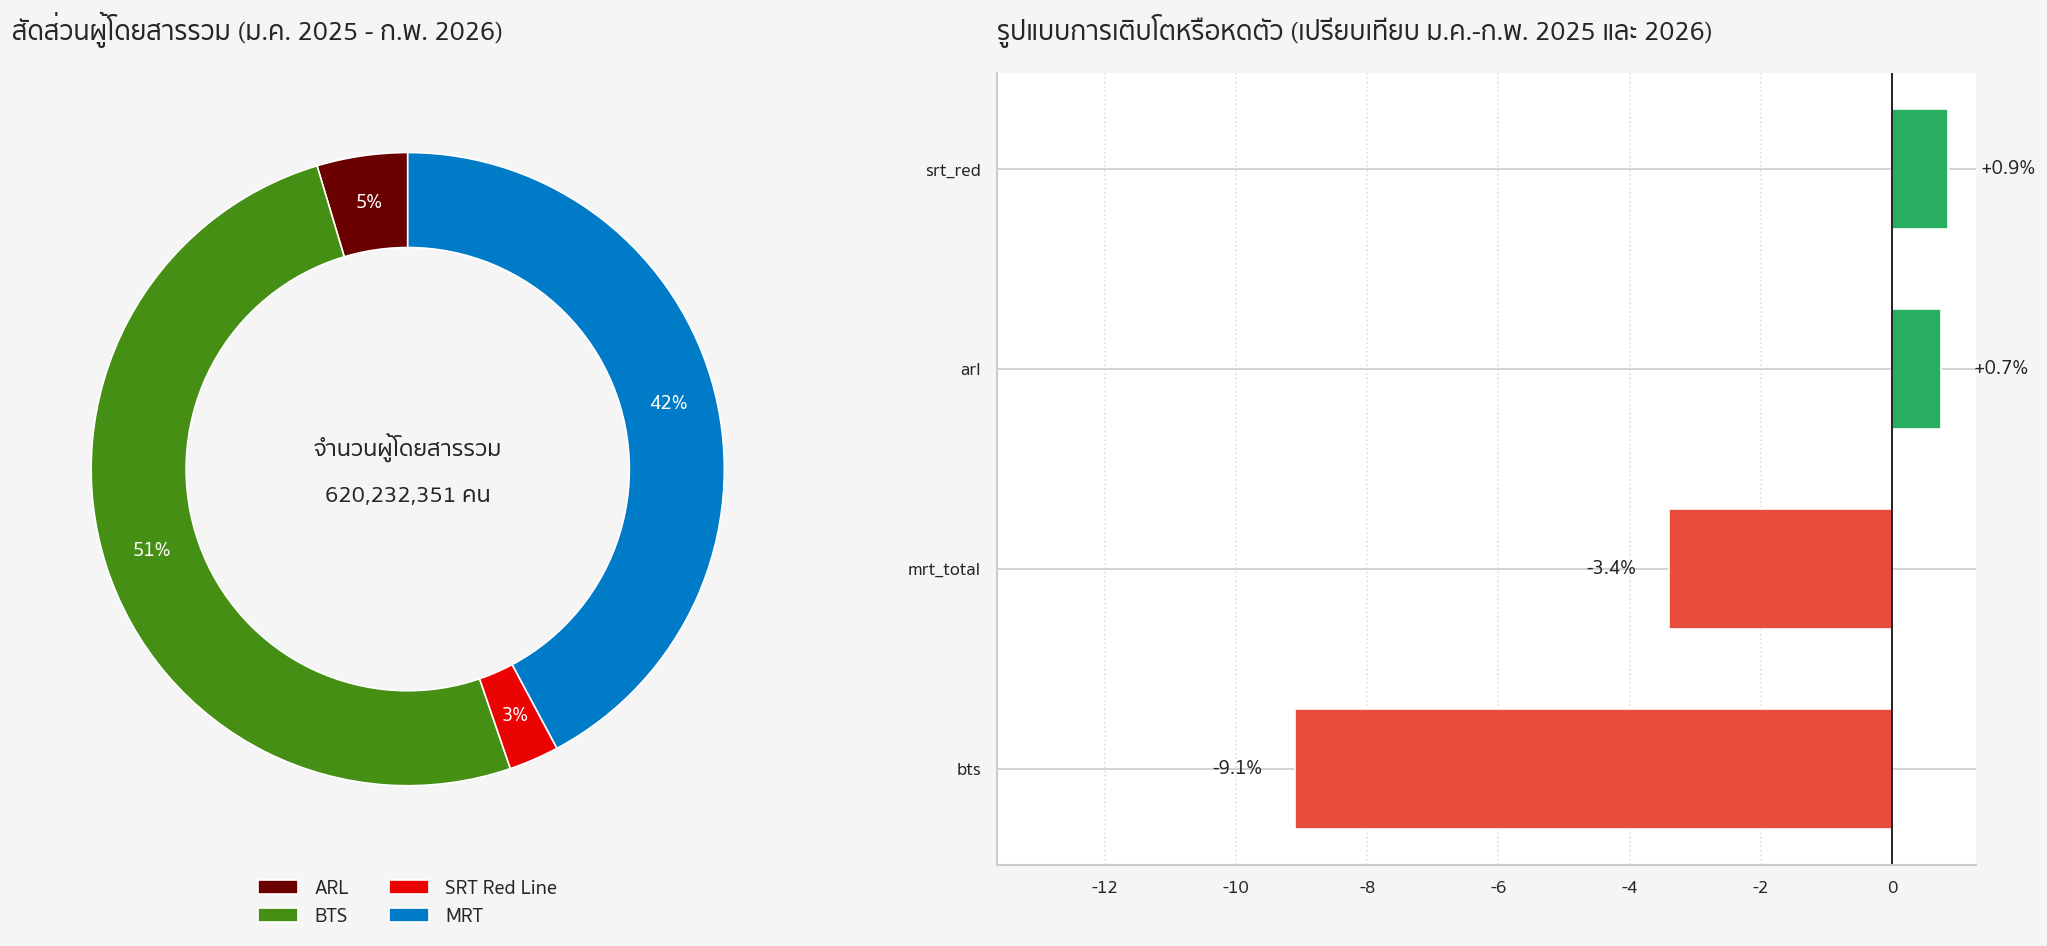

In [225]:
# จัดกลุ่มข้อมูล (Groupby) ตามปี และรวมสายรถไฟฟ้า
by_line = df_filtered.groupby('Year')[['arl', 'bts', 'srt_red', 'mrt_total']].sum().T

# คำนวณ % Growth
by_line['change_pct'] = ((by_line[2026] - by_line[2025]) / by_line[2025]) * 100
by_line = by_line.sort_values('change_pct', ascending=True)

target_columns = ['arl', 'bts', 'srt_red', 'mrt_total']
total_values = df_first[target_columns].sum()

labels = ['ARL', 'BTS', 'SRT Red Line', 'MRT']
colors_donut = ['#6B0000', '#468f15', '#EB0202', '#007bc7']

# --- สร้าง figure ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#f5f5f5')

# --- กราฟซ้าย: Donut Chart (สัดส่วนรวมทุกปี) ---
wedges, texts, autotexts = axes[0].pie(
    total_values,
    autopct='%1.0f%%',
    startangle=90,
    colors=colors_donut,
    pctdistance=0.85,
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'}
)

# สร้างวงกลมตรงกลาง
centre_circle = plt.Circle((0,0), 0.70, fc='#f5f5f5')
axes[0].add_artist(centre_circle)

# เพิ่มข้อความ บอกยอดรวม ตรงกลาง Donut
total_all_systems = total_values.sum()
axes[0].text(0, 0, f'จำนวนผู้โดยสารรวม\n\n{total_all_systems:,.0f} คน',
             ha='center', va='center', fontsize=14, fontweight='bold')

axes[0].set_title('สัดส่วนผู้โดยสารรวม (ม.ค. 2025 - ก.พ. 2026)', loc='left', fontsize=16, fontweight='bold', pad=20)

# Legend ด้านล่าง
axes[0].legend(wedges, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1),
              ncol=2, frameon=False, fontsize=12)

# --- กราฟขวา: % Change (แท่งแนวนอน) ---
by_line_sorted = by_line.sort_values('change_pct', ascending=True)
y_pos = np.arange(len(by_line_sorted))
growth_colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in by_line_sorted['change_pct']]

axes[1].barh(y_pos, by_line_sorted['change_pct'], color=growth_colors, height=0.6)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(by_line_sorted.index, fontsize=11)
axes[1].set_title('รูปแบบการเติบโตหรือหดตัว (เปรียบเทียบ ม.ค.-ก.พ. 2025 และ 2026)', loc='left', fontsize=16, fontweight='bold', pad=20)

# ปรับขอบเขตแกน X และเอาเส้นกรอบออกเพื่อความสวยงาม
axes[1].set_xlim(min(by_line_sorted['change_pct'])*1.5, max(by_line_sorted['change_pct'])*1.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

# ใส่ตัวเลข % กำกับปลายแท่ง
for i, v in enumerate(by_line_sorted['change_pct']):
    offset = 0.5 if v >= 0 else -0.5
    align = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:+.1f}%', va='center', ha=align, fontweight='bold')

plt.tight_layout()
plt.show()

**สรุปข้อมูลสำหรับโจทย์ข้อที่ 1**

โดยประกอบไปด้วย
- ข้อมูลพื้นฐาน
- สรุปสัดส่วนผู้โดยสารของรฟฟแต่ละสาย
- สรุปการเติบโตของรฟฟแต่ละสาย

In [226]:
# --- คำนวณข้อมูล ---
total_all_systems = total_values.sum()
growth_data = by_line.sort_values('change_pct', ascending=False)
top_growth = growth_data.iloc[0]
low_growth = growth_data.iloc[-1]

print('='*65)
print(f"{'🚉 สรุปสถิติผู้โดยสารรถไฟฟ้า (Dashboard Summary)':^65}")
print('='*65)

# --- ข้อมูลพื้นฐานและช่วงเวลา ---
print(f" 📅 ช่วงเวลาวิเคราะห์   : มกราคม 2025 - กุมภาพันธ์ 2026")
print(f" 🏗️ ระบบรถไฟฟ้าที่สำรวจ : {len(labels)} สายหลัก (BTS, MRT, ARL, SRT Red)")
print(f" 📊 สถานะการเปรียบเทียบ : ปี 2026 เทียบกับ ปี 2025")
print('-'*65)

# --- สรุปสัดส่วนผู้โดยสารรวม (Donut Chart Data) ---
print(f"{'👥 สถิติผู้โดยสารรวมทุกระบบ':^65}")
print('-'*65)
print(f" ✨ ยอดรวมผู้โดยสารสะสม  : {total_all_systems:,.0f} คน")

# แสดงสัดส่วนผู้โดยสารตามแต่ละสายรฟฟ
for label, value in zip(labels, total_values):
    share = (value / total_all_systems) * 100
    print(f"  📍 {label:<15} : {value:>12,.0f} คน ({share:>5.1f}%)")
print('-'*65)

# --- สรุปการเติบโต (Growth Rate) ---
print(f"{'📈 วิเคราะห์อัตราการเติบโต (% Growth)':^65}")
print('-'*65)
print(f" 🚀 สายที่มีการเติบโตสูงสุด : {top_growth.name.upper():<8} (+{top_growth['change_pct']:.2f}%)")
print(f" 📉 สายที่มีการเติบโตต่ำสุด : {low_growth.name.upper():<8} ({low_growth['change_pct']:.2f}%)")

print('\n [ รายละเอียดการเปลี่ยนแปลงรายสาย ]')
for line, row in growth_data.iterrows():
    status = "🔼" if row['change_pct'] >= 0 else "🔽"
    print(f"  {status} {line.upper():<12} : เปลี่ยนแปลง {row['change_pct']:>+8.2f}%")

print('='*65)

         🚉 สรุปสถิติผู้โดยสารรถไฟฟ้า (Dashboard Summary)         
 📅 ช่วงเวลาวิเคราะห์   : มกราคม 2025 - กุมภาพันธ์ 2026
 🏗️ ระบบรถไฟฟ้าที่สำรวจ : 4 สายหลัก (BTS, MRT, ARL, SRT Red)
 📊 สถานะการเปรียบเทียบ : ปี 2026 เทียบกับ ปี 2025
-----------------------------------------------------------------
                   👥 สถิติผู้โดยสารรวมทุกระบบ                    
-----------------------------------------------------------------
 ✨ ยอดรวมผู้โดยสารสะสม  : 620,232,351 คน
  📍 ARL             :   28,680,717 คน (  4.6%)
  📍 BTS             :  314,037,449 คน ( 50.6%)
  📍 SRT Red Line    :   15,862,537 คน (  2.6%)
  📍 MRT             :  261,651,648 คน ( 42.2%)
-----------------------------------------------------------------
              📈 วิเคราะห์อัตราการเติบโต (% Growth)               
-----------------------------------------------------------------
 🚀 สายที่มีการเติบโตสูงสุด : SRT_RED  (+0.86%)
 📉 สายที่มีการเติบโตต่ำสุด : BTS      (-9.10%)

 [ รายละเอียดการเปลี่ยนแปลงรายสาย ]
  🔼 SRT_RED 

# โจทย์ 2 : — รถไฟฟ้าในกรุงเทพฯ แต่ละสายมีพฤติกรรมผู้โดยสารต่างกันอย่างไร?

**🚇 ข้อ 2 — รถไฟฟ้าในกรุงเทพฯ แต่ละสายมีพฤติกรรมผู้โดยสารต่างกันอย่างไร?**

Urban Rail Comparison

**โจทย์**

จากข้อมูลผู้โดยสารรถไฟฟ้าทุกสาย
- BTS
- MRT สีน้ำเงิน
- MRT สีม่วง
- MRT สีเหลือง
- MRT สีชมพู
- Airport Rail Link
- รถไฟชานเมืองสายสีแดง

จงสร้างกราฟที่เปรียบเทียบ
- ปริมาณผู้โดยสารของแต่ละสาย
- และรูปแบบการเปลี่ยนแปลงของผู้โดยสารรายวัน

พร้อมวิเคราะห์ว่า
- สายใดมี ความผันผวนของผู้โดยสารสูง
- สายใดมี ฐานผู้โดยสารที่เสถียร

In [227]:
# กำหนด Label และสี ในกราฟสำหรับรฟฟทุกสาย

labels = ['ARL', 'BTS', 'MRT Blue', 'MRT Pink', 'MRT Purple', 'MRT Yellow', 'SRT Red']
plot_cols = ['arl', 'bts', 'mrt_blue', 'mrt_pink', 'mrt_purple', 'mrt_yellow', 'srt_red']

color_map = {
    'arl': '#6B0000',
    'bts': '#468f15',
    'mrt_blue': '#191970',
    'mrt_pink': '#FF69B4',
    'mrt_purple': '#800080',
    'mrt_yellow': '#FFD700',
    'srt_red': '#EB0202'
}

In [228]:
# สร้าง Function สำหรับการคำนวณ HeatMap ในแต่ละวันของสัปดาห์
def heatmap():
    df_heat = df_first.copy()
    df_heat['วันที่'] = pd.to_datetime(df_heat['วันที่'])
    df_heat['day_of_week'] = df_heat['วันที่'].dt.day_name()

    df_melted = df_heat.melt(id_vars=['day_of_week'], value_vars=plot_cols,
                            var_name='line', value_name='passengers')

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    ct_heatmap = pd.crosstab(index=df_melted['line'],
                            columns=df_melted['day_of_week'],
                            values=df_melted['passengers'],
                            aggfunc='mean').reindex(columns=days_order)

    ct_heatmap = ct_heatmap / 1000
    ct_heatmap.index = [i.upper().replace('_', ' ') for i in ct_heatmap.index]
    return ct_heatmap

สร้างกราฟที่เปรียบเทียบ
- ปริมาณผู้โดยสารของแต่ละสาย
- และรูปแบบการเปลี่ยนแปลงของผู้โดยสารรายวัน

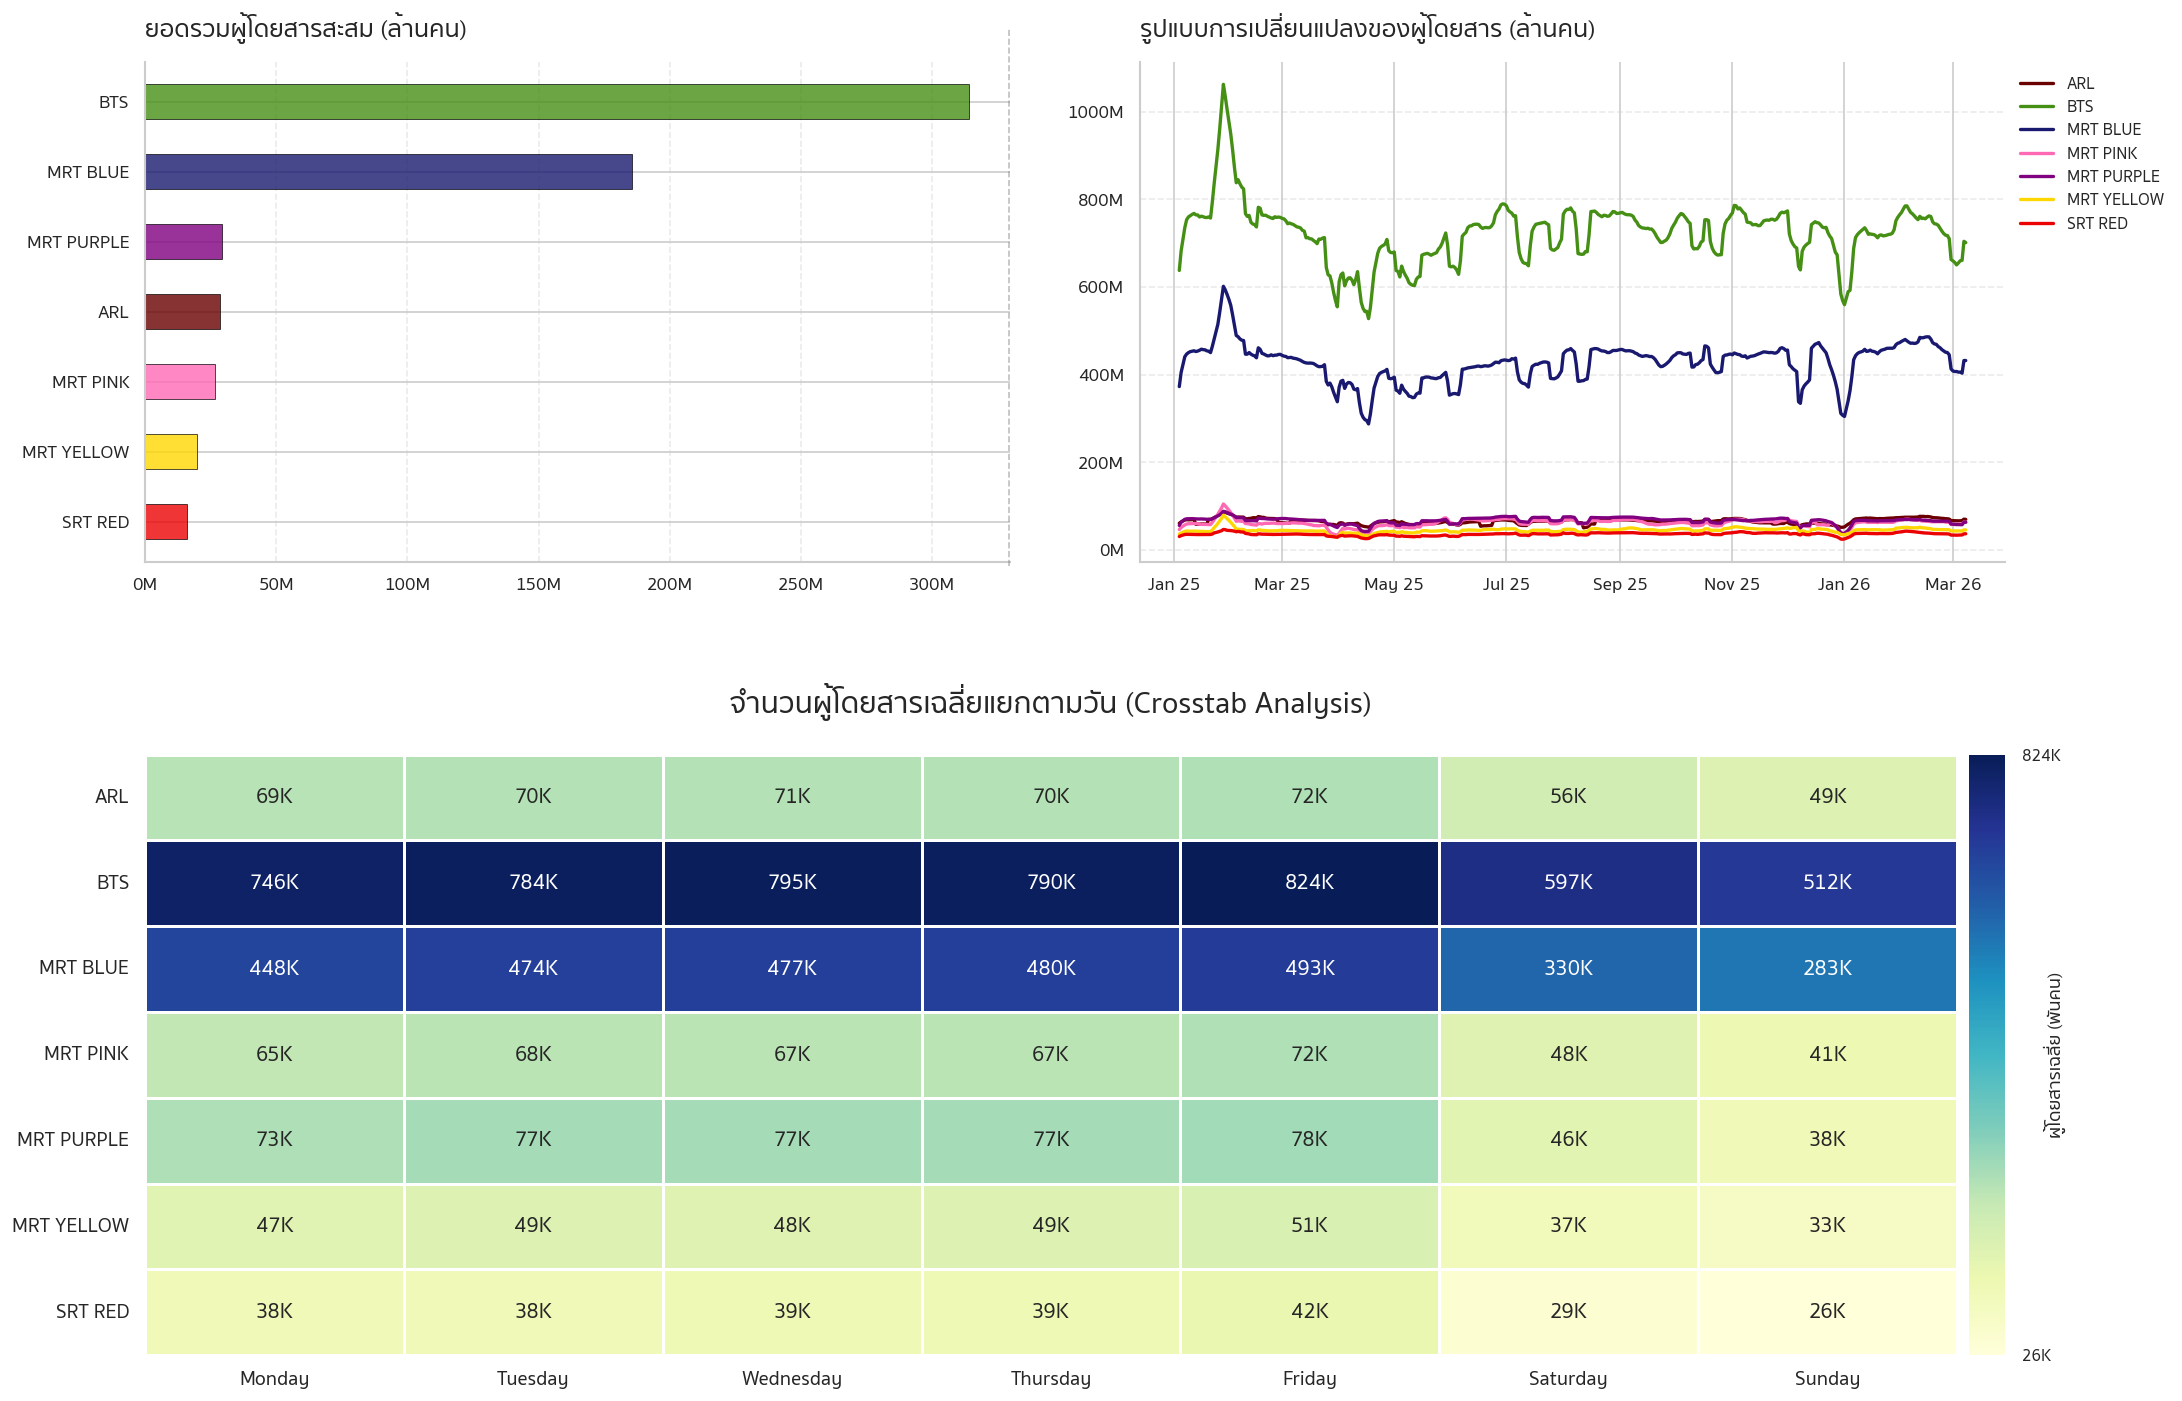

In [229]:
# --- สร้าง figure ---
fig = plt.figure(figsize=(20, 14), constrained_layout=False)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.15)

ax_bar = fig.add_subplot(gs[0, 0])
ax_line = fig.add_subplot(gs[0, 1])
ax_heat = fig.add_subplot(gs[1, :])

# --- กราฟซ้าย Bar Chart  ---
total_m = (df_first[plot_cols].sum().sort_values() / 1_000_000)
labels = [c.upper().replace('_', ' ') for c in total_m.index]
colors = [color_map[c] for c in total_m.index]

bars = ax_bar.barh(labels, total_m, color=colors, height=0.5, edgecolor='black', linewidth=0.5, alpha=0.8)
ax_bar.set_title('ยอดรวมผู้โดยสารสะสม (ล้านคน)', fontsize=15, fontweight='bold', loc='left', pad=15)
ax_bar.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:g}M'))
ax_bar.grid(axis='x', linestyle='--', alpha=0.4)
ax_bar.tick_params(axis='both', which='major', labelsize=11)


# --- กราฟขวา Line Chart ---
for col in plot_cols:
    rolling = (df_first[col] / 1_000).rolling(window=7, center=True).mean()
    ax_line.plot(df_first['วันที่'], rolling, color=color_map[col], label=col.upper().replace('_', ' '), linewidth=2)

ax_line.set_title('รูปแบบการเปลี่ยนแปลงของผู้โดยสาร (ล้านคน)', fontsize=15, fontweight='bold', loc='left', pad=15)
ax_line.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:g}M'))
ax_line.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax_line.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)
ax_line.grid(axis='y', linestyle='--', alpha=0.4)

line = Line2D([0.485, 0.485], [0.58, 0.9], # [x_start, x_end], [y_start, y_end]
              transform=fig.transFigure,
              color='gray',
              linestyle='--',
              linewidth=1,
              alpha=0.5)

fig.add_artist(line)

# --- กราฟล่าง Heat Map ---
ct_heatmap = heatmap()
vmin = ct_heatmap.values.min()
vmax = ct_heatmap.values.max()
annot_text = ct_heatmap.map(lambda x: f"{int(x)}K")

divider = make_axes_locatable(ax_heat)
cax = divider.append_axes("right", size="2%", pad=0.1)

sns.heatmap(ct_heatmap,
            annot=annot_text,
            fmt="",
            cmap="YlGnBu",
            norm=LogNorm(),
            ax=ax_heat,
            cbar_ax=cax,
            annot_kws={"size": 13, "weight": "bold"},
            linewidths=1.5,
            linecolor='white')

# Colorbar Setting
cax.set_yticks([vmin, vmax])

# Line Remove
cax.set_yticklabels([f'{int(vmin)}K', f'{int(vmax)}K'])
cax.tick_params(axis='y', which='both', length=0, width=0)
cax.yaxis.set_minor_locator(ticker.NullLocator())
cax.set_yticks([vmin, vmax])
cax.set_yticklabels([f'{int(vmin)}K', f'{int(vmax)}K'])

for spine in cax.spines.values():
    spine.set_visible(False)

# ปรับรายละเอียดอื่นๆ ของ Colorbar ตามเดิม
cax.set_ylabel('ผู้โดยสารเฉลี่ย (พันคน)', fontsize=11, fontweight='bold', labelpad=-10)
cax.yaxis.set_tick_params(labelsize=10, pad=10)

# ปรับรายละเอียดรอบๆ Heatmap
ax_heat.set_title('จำนวนผู้โดยสารเฉลี่ยแยกตามวัน (Crosstab Analysis)', fontsize=18, fontweight='bold', pad=25)
ax_heat.set_xlabel('', fontsize=12)
ax_heat.set_ylabel('', fontsize=12)
ax_heat.tick_params(axis='x', labelsize=12, rotation=0)
ax_heat.tick_params(axis='y', labelsize=12, rotation=0)

# ลบแกนที่ไม่จำเป็นออก
for ax in [ax_bar, ax_line]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

cbar = ax_heat.collections[0].colorbar
cbar.outline.set_visible(False)

plt.show()

วิเคราะห์ว่า
- สายใดมี ความผันผวนของผู้โดยสารสูง
- สายใดมี ฐานผู้โดยสารที่เสถียร

โดยใช้สูตรในการคำนวณค่าความผันผวนด้วย Coefficient of Variation (CV) หรือ สัมประสิทธิ์ความแปรผัน คือ เครื่องมือทางสถิติที่ใช้เปรียบเทียบ "ความกระจาย" ของข้อมูล โดยเทียบเป็น เปอร์เซ็นต์ (%)


---


CV คำนวณได้จากการนำ ส่วนเบี่ยงเบนมาตรฐาน (SD) หารด้วย ค่าเฉลี่ย (μ) แล้วคูณด้วย 100

$$CV = \left( \frac{\sigma}{\mu} \right) \times 100$$

**โดยที่:**
* $\sigma$ คือ ส่วนเบี่ยงเบนมาตรฐาน (Standard Deviation)
* $\mu$ คือ ค่าเฉลี่ย (Mean)

In [230]:
def cv_anylysis(total_sum,analysis):
  most_volatile = analysis['CV%'].idxmax()
  print(f"📈 [ วิเคราะห์ความผันผวน (เรียงจากผันผวนมากไปน้อย) ]")
  print(f"{'-'*70}")
  vol_sorted = analysis.sort_values('CV%', ascending=False)
  for idx, row in vol_sorted.iterrows():
      # Visual (Bar)
      bar_len = int(row['CV%'] / 5)
      bar_visual = '█' * bar_len
      print(f"{idx.upper().replace('_', ' '):<15} : {row['CV%']:>6.2f}% {bar_visual}")

  print(f"\n⚠️ สายที่ผันผวนสูงสุด : {most_volatile.upper().replace('_', ' ')} (CV {analysis.loc[most_volatile, 'CV%']:.2f}%)")
  print(f"✅ สายที่เสถียรที่สุด : {most_stable.upper().replace('_', ' ')} (CV {analysis.loc[most_stable, 'CV%']:.2f}%)")

**สรุปข้อมูลสำหรับโจทย์ข้อที่ 2**

โดยประกอบไปด้วย
- สรุปภาพรวมปริมาณ
- วิเคราะห์ความผันผวน


In [231]:
df_lines = df_first[plot_cols]
total_sum = df_lines.sum()

analysis = pd.DataFrame({
      'Total (M)': total_sum / 1_000_000,
      'Daily Mean': df_lines.mean(),
      'Std Dev': df_lines.std()
  })
analysis['CV%'] = (analysis['Std Dev'] / analysis['Daily Mean']) * 100
analysis = analysis.sort_values('Total (M)', ascending=False)

# ดึงค่าสูงสุด/ต่ำสุดมาทำสรุป
most_used = analysis['Total (M)'].idxmax()
most_stable = analysis['CV%'].idxmin()

print("\n" + "="*70)
print(f"{'🚆 รายงานสรุปภาพรวมและเสถียรภาพโครงข่ายรถไฟฟ้า':^70}")
print("="*70)

# --- สรุปภาพรวมปริมาณ ---
print(f"📊 [ สรุปยอดผู้โดยสารสะสม ]")
print(f"{'-'*70}")
print(f"{'สายรถไฟฟ้า':<15} | {'จำนวนรวม (ล้านคน)':>18} | {'เฉลี่ยรายวัน (คน)':>18}")
print(f"{'-'*70}")
for idx, row in analysis.iterrows():
    name = idx.upper().replace('_', ' ')
    print(f"{name:<15} | {row['Total (M)']:>16.2f}M | {row['Daily Mean']:>18,.0f}")

print(f"\n💡 ระบบที่มีผู้ใช้บริการสูงสุด: {most_used.upper().replace('_', ' ')}")
print(f"{'-'*70}")

# --- วิเคราะห์ความผันผวน ---
cv_anylysis(total_sum,analysis)
print("="*70)


            🚆 รายงานสรุปภาพรวมและเสถียรภาพโครงข่ายรถไฟฟ้า             
📊 [ สรุปยอดผู้โดยสารสะสม ]
----------------------------------------------------------------------
สายรถไฟฟ้า      |  จำนวนรวม (ล้านคน) |  เฉลี่ยรายวัน (คน)
----------------------------------------------------------------------
BTS             |           314.04M |            721,925
MRT BLUE        |           185.78M |            427,072
MRT PURPLE      |            29.27M |             67,299
ARL             |            28.68M |             65,933
MRT PINK        |            26.83M |             61,682
MRT YELLOW      |            19.77M |             45,446
SRT RED         |            15.86M |             36,466

💡 ระบบที่มีผู้ใช้บริการสูงสุด: BTS
----------------------------------------------------------------------
📈 [ วิเคราะห์ความผันผวน (เรียงจากผันผวนมากไปน้อย) ]
----------------------------------------------------------------------
MRT PURPLE      :  29.29% █████
MRT PINK        :  26.98% █████
MRT BLUE

# โจทย์ 3 - วันหยุดและเทศกาลเห็นได้ในข้อมูลไหม?

**📅 ข้อ 3 — วันหยุดและเทศกาลเห็นได้ในข้อมูลไหม?**

Event Detection

โจทย์
จากข้อมูลผู้โดยสาร **รายวันตลอด 14 เดือน**

จงสร้างกราฟที่สามารถ

- ตรวจจับ จุดผิดปกติ (Anomaly) ในปริมาณการเดินทาง
- และระบุให้ได้ว่า

จุดที่

- พุ่งสูงผิดปกติ
- ลดลงอย่างมาก

สอดคล้องกับเหตุการณ์ใด เช่น

- วันหยุดยาว
- เทศกาล
- นโยบายหรือเหตุการณ์สำคัญ

In [232]:
# กลับมาใช้ข้อมูล DataFrame ที่รวมทุกประเภทการโดยสาร
df_all

,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,2025-01-01,คน,127551.0
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,2025-01-01,คน,8218.0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),2025-01-01,คัน,877943.0
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),2025-01-01,คัน,932642.0
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),2025-01-01,คัน,1364992.0
...,...,...,...,...,...,...,...,...
18701,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานดอนเมือง ขาออกประเทศ,2026-03-11,คน,16641.0
18702,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ,2026-03-11,คน,12741.0
18703,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,2026-03-11,คน,11625.0
18704,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,2026-03-11,คน,998.0


In [233]:
# สร้าง DataFrame ใหม่แบ่งกลุ่มเป็นปริมาณรวมตามแต่ละวัน
daily_df = df_all.groupby('วันที่')['ปริมาณ'].sum().reset_index()

# เพิ่ม Comlumn ว่าเป็นวันอะไรของสัปดาห์ และเป็นหยุด เสาร์-อาทิตย์ หรือไม่
daily_df['day_of_week'] = daily_df['วันที่'].dt.day_name()
daily_df['is_weekend'] = daily_df['วันที่'].dt.dayofweek >= 5

print('✅ สร้าง DataFrame ใหม่แล้วเรียบร้อย')
daily_df

✅ สร้าง DataFrame ใหม่แล้วเรียบร้อย


,วันที่,ปริมาณ,day_of_week,is_weekend
0,2025-01-01,6674990.0,Wednesday,False
1,2025-01-02,6989121.0,Thursday,False
2,2025-01-03,7743758.0,Friday,False
3,2025-01-04,7146715.0,Saturday,True
4,2025-01-05,7035727.0,Sunday,True
...,...,...,...,...
430,2026-03-07,5727336.0,Saturday,True
431,2026-03-08,4932783.0,Sunday,True
432,2026-03-09,6190960.0,Monday,False
433,2026-03-10,6313884.0,Tuesday,False


In [234]:
# ดึงข้อมูลวันหยุดไทยมาจาก library holidays
th_holidays = holidays.Thailand(years=[2025, 2026])


# โชว์ตัวอย่างข้อมูลวันหยุดไทย
df_holidays = pd.DataFrame(list(th_holidays.items()), columns=['วันที่', 'ชื่อวันหยุด']).sort_values('วันที่')
display_df = pd.concat([df_holidays.head(3), df_holidays.tail(3)]).drop_duplicates()

styled_df = display_df.style.set_properties(**{'text-align': 'left'})\
    .set_table_styles([
        dict(selector='th', props=[('text-align', 'center'),
                                   ('font-weight', 'bold')])
    ])

print('--- ตัวอย่างวันหยุด ---')
styled_df

--- ตัวอย่างวันหยุด ---


,วันที่,ชื่อวันหยุด
0,2025-01-01,New Year's Day
1,2025-01-11,National Children's Day
19,2025-02-12,Makha Bucha
34,2026-12-07,HM King Bhumibol Adulyadej the Great's Birthday (in lieu); National Day (in lieu); National Father's Day (in lieu)
41,2026-12-10,Constitution Day
42,2026-12-31,New Year's Eve


In [235]:
# ระบุ วันหยุดในแต่ละวันว่าตรงกับวันไหนบ้างใน DataFrame
daily_df['holiday_name'] = daily_df['วันที่'].apply(lambda x: th_holidays.get(x))
daily_df['is_holiday'] = daily_df['holiday_name'].notna()
print('✅ Mapping วันหยุดแล้วเรียบร้อย')

✅ Mapping วันหยุดแล้วเรียบร้อย


สร้างกราฟที่สามารถ
- ตรวจจับ จุดผิดปกติ (Anomaly) ในปริมาณการเดินทาง



---

โดยใช้หลักการคำนวณ Rolling Z-Score เพื่อระบุว่าข้อมูล ณ วันนั้น แตกต่าง ออกจากค่าเฉลี่ยปกติในช่วงเวลานั้นมากน้อยแค่ไหน โดยมีสูตรคำนวณคือ

$$Z = \frac{x - \mu_{rolling}}{\sigma_{rolling}}$$

โดยที่
* **$x$:** ปริมาณผู้โดยสารจริง ณ วันที่ตรวจสอบ
* **$\mu_{rolling}$:** ค่าเฉลี่ยเคลื่อนที่ (Rolling Mean) ย้อนหลัง 21 วัน
* **$\sigma_{rolling}$:** ส่วนเบี่ยงเบนมาตรฐานเคลื่อนที่ (Rolling Std) ย้อนหลัง 21 วัน

เมื่อพบว่าเป็น Anomaly แล้วจะทำแยกประเภทเป็น:
- Spike (Positive Z-Score): ปริมาณสูงผิดปกติ
- Drop (Negative Z-Score): ปริมาณต่ำผิดปกติ

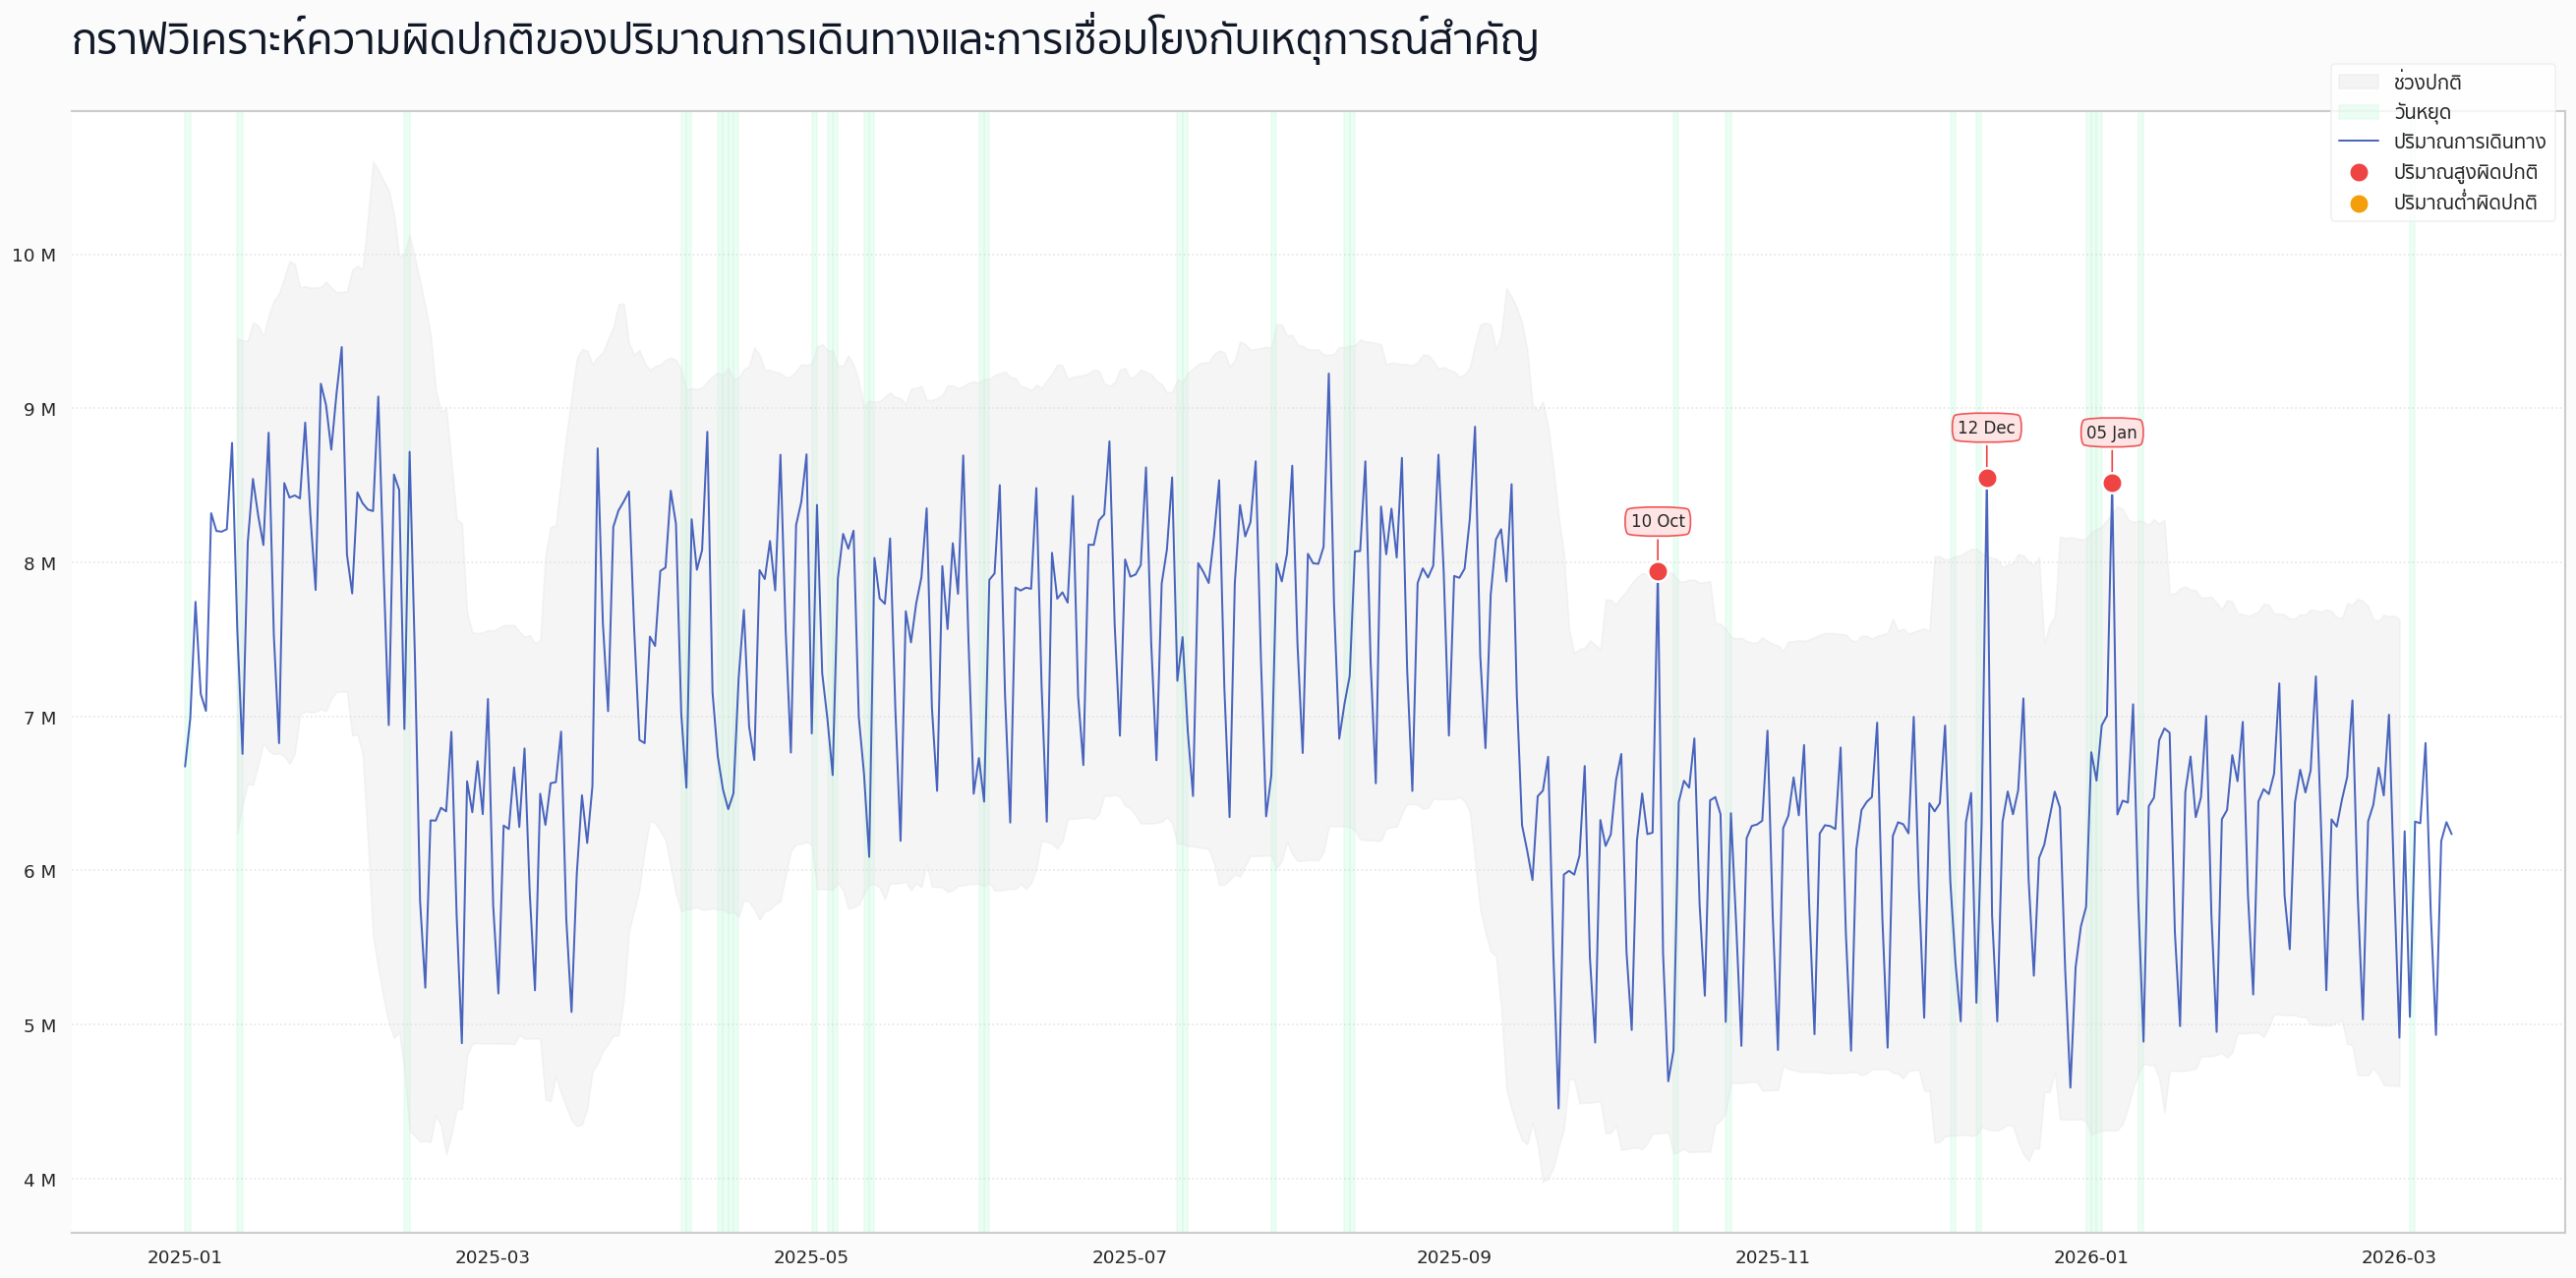

In [236]:
# --- คำนวณ Anomaly ด้วย Rolling Z-Score ---
window = 21
daily_df['rolling_mean'] = daily_df['ปริมาณ'].rolling(window=window, center=True).mean()
daily_df['rolling_std'] = daily_df['ปริมาณ'].rolling(window=window, center=True).std()
daily_df['z_score'] = (daily_df['ปริมาณ'] - daily_df['rolling_mean']) / daily_df['rolling_std']

threshold_high = 2.3
threshold_low = 2.3

daily_df['is_anomaly'] = (daily_df['z_score'] > threshold_high) | (daily_df['z_score'] < -threshold_low)
daily_df['anomaly_type'] = 'Normal'
daily_df.loc[(daily_df['is_anomaly']) & (daily_df['z_score'] > 0), 'anomaly_type'] = 'Spike'
daily_df.loc[(daily_df['is_anomaly']) & (daily_df['z_score'] < 0), 'anomaly_type'] = 'Drop'


# --- สร้าง Figure ---
plt.figure(figsize=(22, 11), facecolor='#fbfbfb') # เปลี่ยนพื้นหลัง figure ให้ดูสบายตา
sns.set_style("whitegrid", {'axes.grid': False})

# วาดเส้น Confidence Interval
upper_bound = daily_df['rolling_mean'] + (threshold_high * daily_df['rolling_std'])
lower_bound = daily_df['rolling_mean'] - (threshold_low * daily_df['rolling_std'])

plt.fill_between(daily_df['วันที่'], lower_bound, upper_bound,
                 color='#e0e0e0', alpha=0.3, label='ช่วงปกติ', zorder=1)

# วาดแถบวันหยุดสีเขียว
first_holiday = True

for d in daily_df[daily_df['is_holiday']]['วันที่']:
    if first_holiday:
        plt.axvspan(d, d + pd.Timedelta(days=1), color='#d1fae5', alpha=0.4,
                    label='วันหยุด', zorder=0)
        first_holiday = False
    else:
        plt.axvspan(d, d + pd.Timedelta(days=1), color='#d1fae5', alpha=0.4, zorder=0)

# วาดเส้นปริมาณ
plt.plot(daily_df['วันที่'], daily_df['ปริมาณ'], color='#1e40af', linewidth=1.2,
         label='ปริมาณการเดินทาง', alpha=0.8, zorder=3)

# วาดจุด Anomaly
spikes = daily_df[daily_df['anomaly_type'] == 'Spike']
drops = daily_df[daily_df['anomaly_type'] == 'Drop']

plt.scatter(spikes['วันที่'], spikes['ปริมาณ'], color='#ef4444', s=150, edgecolors='white',
            linewidth=1.5, label='ปริมาณสูงผิดปกติ', zorder=10)
plt.scatter(drops['วันที่'], drops['ปริมาณ'], color='#f59e0b', s=150, edgecolors='white',
            linewidth=1.5, label='ปริมาณต่ำผิดปกติ', zorder=10)

# Anomaly Annotation
for i, row in daily_df[daily_df['is_anomaly']].iterrows():
    label_text = row['holiday_name'] if pd.notna(row['holiday_name']) else row['วันที่'].strftime('%d %b')

    is_spike = row['anomaly_type'] == 'Spike'
    fc_color = '#fee2e2' if is_spike else '#fef3c7'
    ec_color = '#ef4444' if is_spike else '#f59e0b'

    plt.annotate(label_text,
                 (row['วันที่'], row['ปริมาณ']),
                 textcoords="offset points",
                 xytext=(0, 25 if is_spike else -30),
                 ha='center',
                 va='bottom' if is_spike else 'top',
                 fontsize=10,
                 bbox=dict(boxstyle='round4,pad=0.4', fc=fc_color, ec=ec_color, alpha=0.9),
                 arrowprops=dict(arrowstyle='-', color=ec_color, lw=1))

# ปรับแต่ง Style
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')



# ปรับแต่ง Legend
plt.legend(loc='upper right',
           frameon=True,
           facecolor='white',
           edgecolor='#eeeeee',
           prop=prop,  # บังคับใช้ฟอนต์ Sukhumvit ตรงๆ
           ncol=1,
           bbox_to_anchor=(1, 1.05))

prop.set_size(26)
plt.title('กราฟวิเคราะห์ความผิดปกติของปริมาณการเดินทางและการเชื่อมโยงกับเหตุการณ์สำคัญ',
           pad=35, color='#111827', loc='left', fontproperties=prop)

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [237]:
# ดึงข้อมูลเฉพาะวันที่มี Anomaly
anomaly_summary = daily_df[daily_df['is_anomaly']].copy()

columns_to_show = ['วันที่', 'ปริมาณ', 'z_score', 'anomaly_type', 'holiday_name', 'is_holiday','is_weekend']
available_columns = [col for col in columns_to_show if col in anomaly_summary.columns]

anomaly_table = anomaly_summary[available_columns].sort_values(by='วันที่')

print("--- ตารางสรุปรายการ Anomaly ---")
print(anomaly_table.to_string(index=False))

--- ตารางสรุปรายการ Anomaly ---
    วันที่    ปริมาณ  z_score anomaly_type holiday_name  is_holiday  is_weekend
2025-10-10 7941486.0 2.349033        Spike         None       False       False
2025-12-12 8551237.0 2.930198        Spike         None       False       False
2026-01-05 8520193.0 2.531440        Spike         None       False       False


จากการคำนวณแล้วพบว่ามีวันที่เป็น Anomaly ทั้งหมด 3 วันแต่ไม่มีวันไหนเป็นวันหยุดเลย จึงทำการคำนวณหาวันหยุดที่ใกล้กับวันที่เป็น Anomaly เนื่องจากจะมีวันประเภทหนึ่งซึ่งเรียกว่า Pyler Week ที่จะเป็นวันที่คนลาหยุดก่อนวันหยุด เพื่อเพิ่มเวลาในการเที่ยว



---

ดังนั้นจึงจะทำการคำนวณหาวันหยุดที่ใกล้กับวันที่เป็น Anomaly ห่างกัน 7 วันและทำการแสดงประเภทการเดินทางที่มีปริมาณเยอะที่สุด


In [238]:
# --- ดึงข้อมูลจาก df_all ว่าวันที่เป็น anomaly มีการโดยสารอะไรมากที่สุด ---
idx = df_all.groupby('วันที่')['ปริมาณ'].idxmax()
top_transport = df_all.loc[idx, ['วันที่', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'ปริมาณ']]
top_transport.columns = ['วันที่', 'top_agency', 'top_vehicle', 'max_volume']

anomaly_summary = daily_df[daily_df['is_anomaly']].copy()

anomaly_with_top = pd.merge(
        anomaly_summary,
        top_transport,
        on='วันที่',
        how='left'
)

# เตรียมข้อมูลวันหยุด
holidays_lookup = daily_df[daily_df['is_holiday'] & daily_df['holiday_name'].notna()][['วันที่', 'holiday_name']].copy()

def find_nearby_holiday(current_date, holiday_df, window_days=7):
    # คำนวณความต่างของวัน
    diffs = (holiday_df['วันที่'] - current_date).dt.days

    # กรองเอาเฉพาะที่อยู่ในช่วง -7 ถึง +7 วัน
    nearby = holiday_df[(diffs.abs() <= window_days)].copy()

    if nearby.empty:
        return "None"

    # หาตัวที่ใกล้ที่สุด
    nearby['dist'] = (nearby['วันที่'] - current_date).dt.days.abs()
    closest = nearby.sort_values('dist').iloc[0]

    dist_val = (closest['วันที่'] - current_date).days
    direction = "หลัง" if dist_val > 0 else "ก่อน"

    if dist_val == 0:
        return f"{closest['holiday_name']}"
    else:
        return f"{closest['holiday_name']} ({abs(dist_val)} วัน{direction})"

# นำฟังก์ชันไปใช้กับ anomaly_with_top
anomaly_with_top['nearby_event'] = anomaly_with_top['วันที่'].apply(
    lambda x: find_nearby_holiday(x, holidays_lookup, window_days=7)
)


# --- สร้าง Table ---
columns_to_show = [
    'วันที่', 'ปริมาณ', 'z_score', 'anomaly_type',
    'nearby_event', 'top_agency', 'top_vehicle'
]
anomaly_table = anomaly_with_top[columns_to_show].sort_values(by='วันที่')


def highlight_anomaly(s):
    if s.anomaly_type == 'Spike':
      return ['background-color: #fee2e2; color: #b91c1c; font-weight: bold'] * len(s)
    elif s.anomaly_type == 'Drop':
      return ['background-color: #fef3c7; color: #92400e; font-weight: bold'] * len(s)
    return [''] * len(s)

anomaly_table = (anomaly_table.style
                .format({
                    'วันที่': lambda t: t.strftime('%d %b %Y'),
                    'ปริมาณ': '{:,.0f}',
                    'z_score': '{:.2f}'
                })
                .apply(highlight_anomaly, axis=1) # ใช้ฟังก์ชัน highlight เดิมที่คุณมี
                .hide(axis='index')
                .set_caption("ตารางสรุปความผิดปกติในการเดินทาง")
                .set_table_styles([
                    {'selector': 'th', 'props': [('background-color', '#1e40af'), ('color', 'white'), ('font-weight', 'bold')]}
                ]))

display(anomaly_table)

วันที่,ปริมาณ,z_score,anomaly_type,nearby_event,top_agency,top_vehicle
10 Oct 2025,"7,941,486",2.35,Spike,HM King Bhumibol Adulyadej Memorial Day (3 วันหลัง),กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)
12 Dec 2025,"8,551,237",2.93,Spike,Constitution Day (2 วันก่อน),กทพ.,รถยนต์ทุกประเภท (ทางด่วน)
05 Jan 2026,"8,520,193",2.53,Spike,Bridge Public Holiday (3 วันก่อน),กทพ.,รถยนต์ทุกประเภท (ทางด่วน)


**สรุปข้อมูลสำหรับโจทย์ข้อที่ 3**

โดยประกอบไปด้วย
- ข้อมูลเบื้องต้น
- สรุปผลตรวจพบความผิดปกติ
- วิเคราะห์ความเชื่อมโยงกับเหตุการณ์



In [239]:
def generate_executive_report(styled_df, daily_df):
    data = styled_df.data if hasattr(styled_df, 'data') else styled_df

    total_anomalies = len(data)
    spikes = data[data['anomaly_type'] == 'Spike']
    drops = data[data['anomaly_type'] == 'Drop']

    # คำนวณ Z-score
    avg_spike_z = spikes['z_score'].mean() if not spikes.empty else 0
    avg_drop_z = drops['z_score'].mean() if not drops.empty else 0

    print("="*80)
    print(f"📊 สรุปวิเคราะห์ความผิดปกติการเดินทาง")
    print(f"วิเคราะห์ในช่วงวันที่: {daily_df['วันที่'].min().strftime('%d %b %Y')} ถึง {daily_df['วันที่'].max().strftime('%d %b %Y')}")
    print("="*80)

    # --- Overall ---
    print(f"✅ ตรวจพบความผิดปกติทั้งหมด: {total_anomalies} เหตุการณ์")
    print(f"   • ปริมาณพุ่งสูง (Spikes): {len(spikes)} ครั้ง (Z-Score เฉลี่ย: +{avg_spike_z:.2f})")
    print(f"   • ปริมาณลดลง (Drops):  {len(drops)} ครั้ง (Z-Score เฉลี่ย: {avg_drop_z:.2f})")
    print("-" * 80)

    # --- Root Cause Analysis ---
    print(f"🔍 วิเคราะห์ความเชื่อมโยงกับเหตุการณ์:")

    # หาวันหยุดใกล้เคียง
    bridge_days = data[data['nearby_event'].str.contains('วันก่อน|วันหลัง', na=False)]
    exact_holidays = data[~data['nearby_event'].str.contains('วันก่อน|วันหลัง|None', na=False)]
    unknowns = data[data['nearby_event'] == 'None']

    if not exact_holidays.empty:
        print(f"   📍 ตรงกับวันหยุดนักขัตฤกษ์: {len(exact_holidays)} ครั้ง")
    if not bridge_days.empty:
        print(f"   📍 ช่วงรอยต่อวันหยุด (Bridge Days): {len(bridge_days)} ครั้ง (มีผลกระทบต่อปริมาณการเดินทางอย่างมีนัยสำคัญ)")

    # วันที่ไม่พบสาเหตุจากวันหยุด
    if not unknowns.empty:
        print(f"   ⚠️ ไม่พบความเชื่อมโยงกับวันหยุด: {len(unknowns)} ครั้ง (ควรตรวจสอบปัจจัยอื่นๆ เช่น สภาพอากาศ หรือ อุบัติเหตุ)")
    print("-" * 80)

    # --- Key Highlights ---
    print(f"🏆 เหตุการณ์สำคัญที่ตรวจพบ:")

    # Max Spike
    if not spikes.empty:
        max_s = spikes.loc[spikes['z_score'].idxmax()]
        print(f"   🚀 พุ่งสูงสุด: {max_s['วันที่'].strftime('%d %b %Y')} | หน่วยงานหลัก: {max_s['top_agency']} ({max_s['top_vehicle']})")
        if max_s['nearby_event'] != 'None':
            print(f"      หมายเหตุ: สอดคล้องกับ {max_s['nearby_event']}")

    # Min Drop
    if not drops.empty:
        min_d = drops.loc[drops['z_score'].idxmin()]
        print(f"   📉 ลดลงต่ำสุด:  {min_d['วันที่'].strftime('%d %b %Y')} | หน่วยงานหลัก: {min_d['top_agency']} ({min_d['top_vehicle']})")
        if min_d['nearby_event'] != 'None':
            print(f"      หมายเหตุ: สอดคล้องกับ {min_d['nearby_event']}")

    print("="*80)

generate_executive_report(anomaly_with_top, daily_df)

📊 สรุปวิเคราะห์ความผิดปกติการเดินทาง
วิเคราะห์ในช่วงวันที่: 01 Jan 2025 ถึง 11 Mar 2026
✅ ตรวจพบความผิดปกติทั้งหมด: 3 เหตุการณ์
   • ปริมาณพุ่งสูง (Spikes): 3 ครั้ง (Z-Score เฉลี่ย: +2.60)
   • ปริมาณลดลง (Drops):  0 ครั้ง (Z-Score เฉลี่ย: 0.00)
--------------------------------------------------------------------------------
🔍 วิเคราะห์ความเชื่อมโยงกับเหตุการณ์:
   📍 ช่วงรอยต่อวันหยุด (Bridge Days): 3 ครั้ง (มีผลกระทบต่อปริมาณการเดินทางอย่างมีนัยสำคัญ)
--------------------------------------------------------------------------------
🏆 เหตุการณ์สำคัญที่ตรวจพบ:
   🚀 พุ่งสูงสุด: 12 Dec 2025 | หน่วยงานหลัก: กทพ. (รถยนต์ทุกประเภท (ทางด่วน))
      หมายเหตุ: สอดคล้องกับ Constitution Day (2 วันก่อน)
